# Chapter 1 — What is Radio Astronomy?

!!! info "Before you start"
    **Prerequisites:** none — this is the course's entry point · **Maths Lab:** none · **~30 min** · **Beginner**

> *"I have a problem... the static comes from the same point in the sky every day,
> but it comes around four minutes earlier each day."* — paraphrasing Karl Jansky, 1932

Welcome to **jansky**, a hands-on tour of radio astronomy in Python. This first
chapter sets the stage: we ask what a "radio wave from space" actually *is*, where
it sits in the electromagnetic spectrum, and how a young Bell Labs engineer
stumbled onto a whole new way of looking at the universe while trying to clean up
transatlantic phone calls.

Radio astronomy is a wonderfully friendly corner of astrophysics for a programmer:
the data are **signals**, the maths is **Fourier transforms**, and the tools are
**open source**. Before any of that, though, we need the physical picture and a
feel for the strange units the field lives in.

## Learning goals

By the end of this chapter you will be able to:

- **Place radio waves in the EM spectrum** — explain what cosmic radio emission is
  and why the radio band spans roughly $\sim$1 mm to tens of metres in wavelength.
- **Tell the discovery story** — Karl Jansky's 1932 detection of Galactic static
  and Grote Reber's first radio maps of the sky.
- **Use the jansky unit** — know that $1\,\mathrm{Jy} = 10^{-26}\,\mathrm{W\,m^{-2}\,Hz^{-1}}$,
  and understand the atmospheric **radio window** that lets these waves reach the ground.
- **Explain the 4-minutes-a-day clue** — why a *celestial* source rises about four
  minutes earlier each day (the **sidereal** vs **solar** day), and reproduce the
  drift-scan signature that told Jansky his static was cosmic.

Everything below runs on the base `jansky` environment — no telescope, no network,
just NumPy, Astropy and Matplotlib.

## The history: Jansky's static and Reber's maps

In 1932, **Karl Guthe Jansky** was a 26-year-old radio engineer at Bell Telephone
Laboratories in Holmdel, New Jersey. Bell wanted to use short-wave radio for
transatlantic telephony and needed to understand the sources of static that
corrupted the calls. Jansky built a steerable antenna — a 30 m wide "merry-go-round"
of brass pipe mounted on Ford Model-T wheels — tuned to **20.5 MHz** (a wavelength
of $\lambda \approx 14.6\,$m), and spent months cataloguing every hiss and crackle.

He found three kinds of static: nearby thunderstorms, distant thunderstorms, and a
third, **steady hiss** of unknown origin. At first he thought it tracked the Sun.
But as the weeks went by the peak drifted: it arrived about **four minutes earlier
each day**. Four minutes a day is exactly the difference between the **solar day**
(24 h) and the **sidereal day** (23 h 56 m 04 s) — the rotation period of the Earth
with respect to the *stars* rather than the Sun. The source was not the Sun; it was
fixed to the celestial sphere. Jansky eventually placed it toward the constellation
**Sagittarius** — the direction of the **centre of the Milky Way**. He had detected
radio emission from the Galaxy.

> **Jansky, K. G. (1933).** *Electrical Disturbances Apparently of Extraterrestrial
> Origin.* Proc. IRE **21**, 1387.
> [ADS](https://ui.adsabs.harvard.edu/abs/1933PIRE...21.1387J)
>
> The paper that founded radio astronomy. Jansky reports the steady hiss, shows it
> repeats on the sidereal (not solar) day, and concludes the radiation comes from
> beyond the Solar System, concentrated toward the Milky Way.

Professional astronomers, mostly optical at the time, took little notice. The torch
was picked up by an amateur: **Grote Reber**, a radio engineer in Wheaton, Illinois,
who in 1937 built a 9.6 m parabolic dish *in his back garden*. Over several years of
night-time observing (to avoid car-ignition interference) he produced the **first
contour maps of the radio sky**, confirming Jansky's Galactic-centre source and
finding others. Reber's maps were radio astronomy's first images.

> **Reber, G. (1944).** *Cosmic Static.* ApJ **100**, 279.
> [DOI](https://doi.org/10.1086/144668)
>
> Reber's survey of the sky at 160 MHz, including the first radio contour maps of
> the Milky Way. For a decade, he was very nearly the *only* radio astronomer on Earth.

The unit of radio brightness — the **jansky** — and this course are both named in
Karl Jansky's honour.

## The physics: radio waves, the jansky, and the radio window

### Radio in the EM spectrum

Light of any wavelength obeys the same relation between frequency $\nu$ and
wavelength $\lambda$,

$$ \nu \, \lambda = c, $$

with $c \approx 3\times10^{8}\,\mathrm{m\,s^{-1}}$. The **radio band** is just the
long-wavelength, low-frequency end of the electromagnetic spectrum — conventionally
everything from about a **millimetre** ($\sim$300 GHz) out to tens of **metres**
($\sim$10 MHz). Compared with visible light (around $\lambda \approx 500\,$nm), a
1-metre radio wave is about **two million times longer**.

Cosmic radio emission is produced by several distinct physical mechanisms, all of
which later chapters explore:

- **Thermal (free–free) emission** from hot ionised gas;
- **Synchrotron emission** from relativistic electrons spiralling in magnetic fields
  (this is most of Jansky's Galactic hiss);
- **Spectral lines**, above all the **21 cm line of neutral hydrogen** at 1420 MHz.

### The jansky

Radio sources are faint, and astronomers measure their **spectral flux density** —
power per unit collecting area per unit frequency. The natural SI unit,
$\mathrm{W\,m^{-2}\,Hz^{-1}}$, is enormous for astronomy, so the field uses the
**jansky**:

$$ 1\;\mathrm{Jy} \;\equiv\; 10^{-26}\ \mathrm{W\,m^{-2}\,Hz^{-1}}. $$

For scale, a "strong" radio source is a few Jy; modern surveys reach the
**microjansky**. (We will compute $1\,$Jy in SI with Astropy below, so the constant
is never hard-coded.)

### The radio window

Earth's atmosphere is opaque to most of the EM spectrum — which is why X-ray and
much of the infrared astronomy must be done from space. But it has two broad
**windows** where radiation reaches the ground: the **optical window** and a wide
**radio window**, running from roughly **10 MHz to 300 GHz** ($\sim$1 mm to $\sim$30 m).

The window is bounded at both ends:

- **Low-frequency cutoff** ($\lesssim 10\,$MHz): the **ionosphere** reflects radio
  waves below its plasma frequency, so they never reach the ground from above (and
  ground-based low-frequency signals bounce around the world — which is exactly why
  short-wave radio was useful, and why Jansky was studying it).
- **High-frequency cutoff** ($\gtrsim 300\,$GHz): molecular absorption, chiefly by
  **water vapour** and **molecular oxygen**, makes the atmosphere increasingly murky,
  which is why mm/sub-mm telescopes sit on high, dry mountaintops.

It is precisely this transparency that let radio waves from the Galaxy reach Jansky's
antenna in New Jersey at all.

## Code: setting up

We import NumPy, Matplotlib, Astropy's units/constants, and the `jansky` helper
package. Calling `plotting.use_jansky_style()` early gives every figure in the
course the same clean look.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as const

from jansky import plotting, units

plotting.use_jansky_style()

print("Speed of light c =", const.c)

Speed of light c =   Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2022


### One jansky in SI

Let's confirm the definition with Astropy rather than trusting a remembered number.
Astropy already knows the jansky (`u.Jy`), so we can convert it straight to base SI
units and check it equals $10^{-26}\,\mathrm{W\,m^{-2}\,Hz^{-1}}$.

In [2]:
one_jy = 1 * u.Jy
si = one_jy.to(u.W / u.m**2 / u.Hz)
print(f"1 Jy = {si:.3e}")

# Cross-check against the definition, and use the helper from jansky.units.
definition = 1e-26 * u.W / u.m**2 / u.Hz
assert np.isclose(si.value, definition.value)
print("Matches the definition 1 Jy = 1e-26 W m^-2 Hz^-1:", u.isclose(si, definition))

# units.to_jansky goes the other way: any flux density -> Jy.
print(f"units.to_jansky(1e-26 W m^-2 Hz^-1) = {units.to_jansky(definition):.3g}")

# A 1 Jy source over a 1 MHz band collects a truly tiny power per square metre:
power_per_m2 = (one_jy * (1 * u.MHz)).to(u.W / u.m**2)
print(f"\n1 Jy x 1 MHz = {power_per_m2:.2e}  (per square metre of collecting area)")

1 Jy = 1.000e-26 W / (Hz m2)
Matches the definition 1 Jy = 1e-26 W m^-2 Hz^-1: True
units.to_jansky(1e-26 W m^-2 Hz^-1) = 1 Jy

1 Jy x 1 MHz = 1.00e-20 W / m2  (per square metre of collecting area)


## Figure 1: the EM spectrum and the atmospheric radio window

The top panel lays out the electromagnetic spectrum by wavelength and highlights the
**radio band**. The bottom panel is a **schematic** atmospheric-opacity curve: it
shows *where* the atmosphere is transparent (the optical and radio windows) versus
opaque, but the exact shape is illustrative, not a radiative-transfer calculation.
We build the wavelength grid with Astropy units and convert to frequency with
$\nu = c/\lambda$.

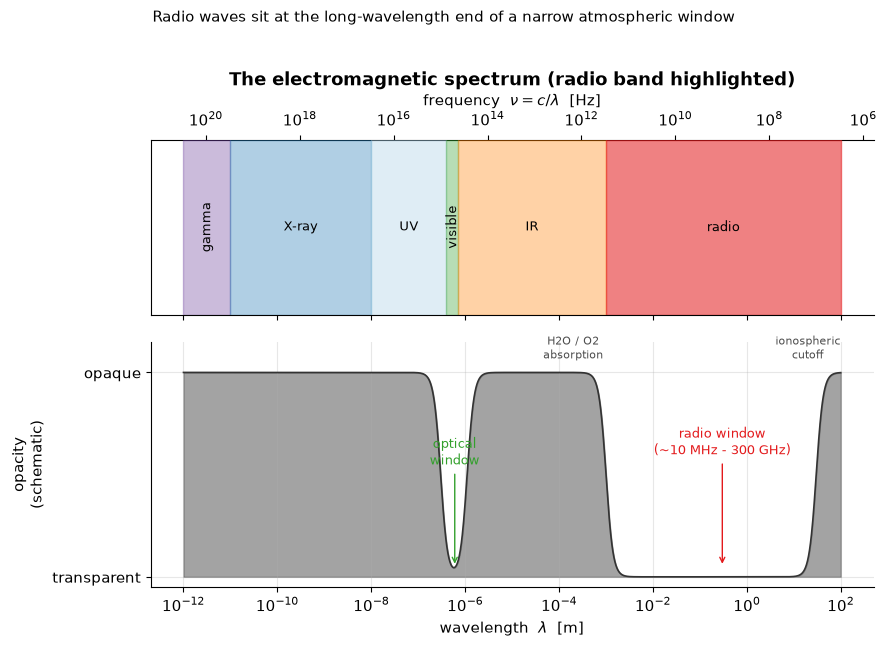

In [3]:
# Wavelength grid spanning gamma rays (1 pm) to long radio waves (100 m).
wavelength = np.logspace(-12, 2, 2000) * u.m
frequency = (const.c / wavelength).to(u.Hz)

# Named EM bands as (label, lambda_min, lambda_max) in metres, for shading.
bands = [
    ("gamma", 1e-12, 1e-11, "#6a3d9a"),
    ("X-ray", 1e-11, 1e-8, "#1f78b4"),
    ("UV", 1e-8, 4e-7, "#a6cee3"),
    ("visible", 4e-7, 7e-7, "#33a02c"),
    ("IR", 7e-7, 1e-3, "#ff7f00"),
    ("radio", 1e-3, 1e2, "#e31a1c"),
]

# --- Schematic atmospheric opacity (0 = transparent, 1 = opaque) ----------
# A clearly-labelled cartoon: two transparent windows (optical + radio) cut
# into an otherwise opaque atmosphere, with edges where physics demands them.
log_lambda = np.log10(wavelength.to_value(u.m))


def _window(logl, lo, hi, softness=0.15):
    "Smooth top-hat transparency window between wavelengths 10**lo and 10**hi (m)."
    return 0.5 * (1 + np.tanh((logl - lo) / softness)) * 0.5 * (1 + np.tanh((hi - logl) / softness))


opacity = np.ones_like(log_lambda)
optical_window = _window(log_lambda, np.log10(3e-7), np.log10(1.1e-6))  # ~300nm-1.1um
radio_window = _window(log_lambda, np.log10(1e-3), np.log10(3e1))  # ~1mm-30m
opacity -= optical_window
opacity -= radio_window
opacity = np.clip(opacity, 0, 1)

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(9, 6.5),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.4]},
)

# Top: band chart -----------------------------------------------------------
for label, lo, hi, color in bands:
    ax_top.axvspan(lo, hi, color=color, alpha=0.55 if label == "radio" else 0.35)
    ax_top.text(
        np.sqrt(lo * hi),
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=9,
        rotation=90 if (hi / lo) < 30 else 0,
    )
ax_top.set_xscale("log")
ax_top.set_yticks([])
ax_top.set_ylim(0, 1)
ax_top.set_title("The electromagnetic spectrum (radio band highlighted)")
ax_top.grid(False)

# Bottom: schematic opacity -------------------------------------------------
ax_bot.fill_between(
    wavelength.to_value(u.m), opacity, color="0.4", alpha=0.6, step=None, label="atmosphere opaque"
)
ax_bot.plot(wavelength.to_value(u.m), opacity, color="0.2", lw=1.2)
ax_bot.set_xscale("log")
ax_bot.set_ylim(-0.05, 1.15)
ax_bot.set_xlabel(r"wavelength  $\lambda$  [m]")
ax_bot.set_ylabel("opacity\n(schematic)")
ax_bot.set_yticks([0, 1])
ax_bot.set_yticklabels(["transparent", "opaque"])

# Annotate the two windows.
ax_bot.annotate(
    "optical\nwindow",
    xy=(6e-7, 0.05),
    xytext=(6e-7, 0.55),
    ha="center",
    fontsize=9,
    color="#33a02c",
    arrowprops=dict(arrowstyle="->", color="#33a02c"),
)
ax_bot.annotate(
    "radio window\n(~10 MHz - 300 GHz)",
    xy=(0.3, 0.05),
    xytext=(0.3, 0.6),
    ha="center",
    fontsize=9,
    color="#e31a1c",
    arrowprops=dict(arrowstyle="->", color="#e31a1c"),
)
ax_bot.text(2e1, 1.05, "ionospheric\ncutoff", ha="center", va="bottom", fontsize=8, color="0.3")
ax_bot.text(2e-4, 1.05, "H2O / O2\nabsorption", ha="center", va="bottom", fontsize=8, color="0.3")


# Secondary frequency axis on top.
def lam_to_freq(lam_m):
    return const.c.value / np.where(lam_m == 0, np.nan, lam_m)


secax = ax_top.secondary_xaxis("top", functions=(lam_to_freq, lam_to_freq))
secax.set_xlabel(r"frequency  $\nu = c/\lambda$  [Hz]")

fig.suptitle(
    "Radio waves sit at the long-wavelength end of a narrow atmospheric window", fontsize=11, y=0.99
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

Two things to take away from Figure 1: radio occupies a *huge* range of wavelengths
(note the log axis — it is by far the widest band), and it is one of only two
spectral regions the atmosphere lets through to the ground. The bottom panel is a
**cartoon** of atmospheric opacity, drawn to show the *windows*, not to predict
transmission at a given frequency.

## The clue: why a star rises 4 minutes earlier each day

The single most important observation in Jansky's discovery was *timing*. A source
fixed to the **Sun** returns to the same place in the sky every **solar day** of
exactly 24 h. A source fixed to the **stars** returns every **sidereal day**.

The Earth both spins on its axis and orbits the Sun. In one year ($\approx 365.25$
days) it makes one extra rotation relative to the stars compared with relative to the
Sun. So the sidereal day is shorter than the solar day by

$$ \Delta t \;\approx\; \frac{24\ \mathrm{h}}{365.25} \;\approx\; 3\ \mathrm{min}\ 56\ \mathrm{s} \;\approx\; 4\ \mathrm{minutes}. $$

The sidereal day is therefore

$$ T_\mathrm{sid} \;=\; 23^\mathrm{h}\,56^\mathrm{m}\,04^\mathrm{s} \;\approx\; 86164\ \mathrm{s}. $$

A celestial source culminates (transits the meridian) one sidereal day apart, so on
the **clock we live by — solar time —** it appears to creep **about four minutes
earlier each day**. Watch this drift accumulate and after about a month a source that
peaked at midnight peaks at 8 pm. That steady, ~4 min/day march is the fingerprint of
something *out among the stars*, and it is exactly what Jansky saw.

In [4]:
SOLAR_DAY = 24 * u.hour
SIDEREAL_DAY = 23 * u.hour + 56 * u.min + 4.0905 * u.s

drift_per_day = (SOLAR_DAY - SIDEREAL_DAY).to(u.min)
# Cross-check via the orbital argument: one extra turn per year.
drift_from_orbit = (SOLAR_DAY / 365.25).to(u.min)

print(f"Sidereal day      = {SIDEREAL_DAY.to(u.s):.1f} = {SIDEREAL_DAY.to(u.hour):.4f}")
print(f"Solar - sidereal  = {drift_per_day:.3f}  per day")
print(f"From 24h / 365.25 = {drift_from_orbit:.3f}  per day  (consistent)")

Sidereal day      = 86164.1 s = 23.9345 h
Solar - sidereal  = 3.932 min  per day
From 24h / 365.25 = 3.943 min  per day  (consistent)


## Figure 2: reproducing Jansky's drift-scan signature

Jansky's antenna swept the sky as the Earth turned (a **drift scan**): a fixed beam
lets the sky rotate past it. A celestial source produces a peak in the record once
per **sidereal** day. If we plot that record against the **solar** clock, the peak
slides earlier by ~4 minutes every day.

We simulate exactly this. The antenna response to a point source on the sky is a
periodic bump (one per sidereal day); we sample it over several days and read off the
**solar-clock time of each daily peak**. We add a little receiver noise so it looks
like a real record — using the seeded generator from `jansky.signals` for
reproducibility.

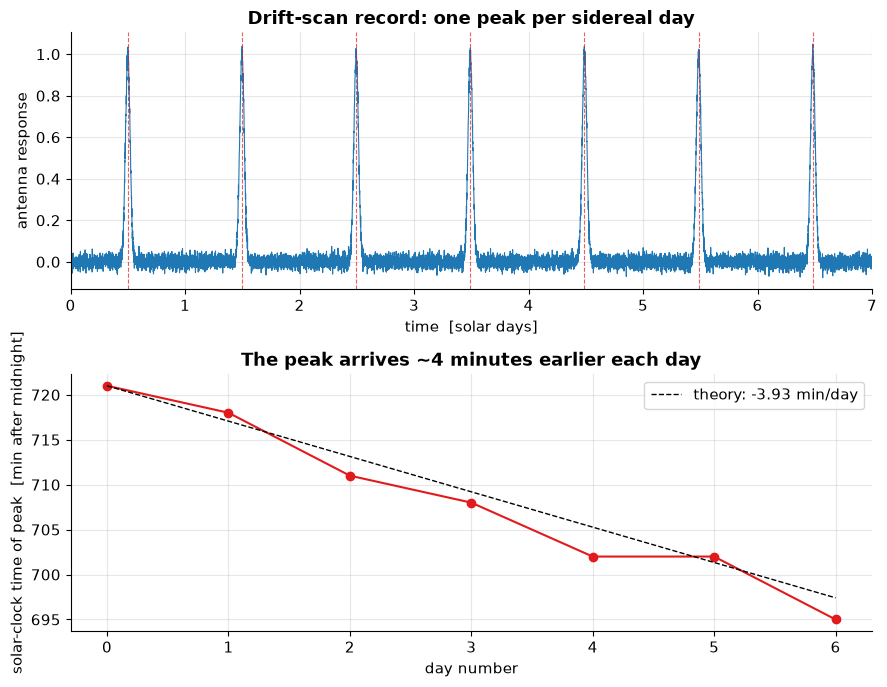

Measured drift   = -4.25 min/day
Expected drift   = -3.93 min/day  (solar - sidereal)

This steady ~-4 min/day march is Jansky's clue: the source keeps
sidereal, not solar, time -- it is fixed among the stars, not the Sun.


In [5]:
from jansky import signals

# --- Simulate the drift-scan record ---------------------------------------
n_days = 7
samples_per_day = 24 * 60  # one sample per solar minute
t_solar = np.arange(0, n_days * samples_per_day) * u.min  # solar-clock time

T_sid = SIDEREAL_DAY.to(u.min).value  # sidereal period, in solar minutes
T_sol = SOLAR_DAY.to(u.min).value  # = 1440

# Source transits once per *sidereal* day. Phase referenced so day-0 peak is at 12:00.
phase0 = 12 * 60  # noon on day 0, in minutes
phase = 2 * np.pi * (t_solar.to_value(u.min) - phase0) / T_sid

# Antenna "beam" as a narrow periodic response (von Mises-like bump per transit).
beam_sharpness = 60.0
response = np.exp(beam_sharpness * (np.cos(phase) - 1.0))

# Add modest receiver noise via the seeded generator from jansky.signals.
noise = signals.rng(seed=1).normal(0.0, 0.02, size=response.shape)
record = response + noise

# --- Find the solar-clock time of each daily peak -------------------------
peak_solar_times = []
for day in range(n_days):
    lo = day * samples_per_day
    hi = (day + 1) * samples_per_day
    idx = lo + np.argmax(record[lo:hi])
    # time-of-day in hours on the solar clock
    peak_solar_times.append((t_solar.to_value(u.min)[idx] % T_sol) / 60.0)
peak_solar_times = np.array(peak_solar_times)

# --- Plot ------------------------------------------------------------------
fig, (axA, axB) = plt.subplots(2, 1, figsize=(9, 7))

# (A) The raw multi-day record vs solar time.
axA.plot(t_solar.to_value(u.day), record, lw=0.8, color="#1f78b4")
for day, hpk in enumerate(peak_solar_times):
    tpk = day + hpk / 24.0
    axA.axvline(tpk, color="#e31a1c", ls="--", lw=0.8, alpha=0.7)
axA.set_xlabel("time  [solar days]")
axA.set_ylabel("antenna response")
axA.set_title("Drift-scan record: one peak per sidereal day")
axA.set_xlim(0, n_days)

# (B) Time-of-peak on the solar clock vs day number -> a ~4 min/day slope.
days = np.arange(n_days)
axB.plot(days, peak_solar_times * 60, "o-", color="#e31a1c")
# Theoretical line: drifts earlier by (solar - sidereal) minutes per day.
slope = -(T_sol - T_sid)  # minutes/day, negative = earlier
intercept = peak_solar_times[0] * 60
axB.plot(days, intercept + slope * days, "k--", lw=1, label=f"theory: {slope:.2f} min/day")
axB.set_xlabel("day number")
axB.set_ylabel("solar-clock time of peak  [min after midnight]")
axB.set_title("The peak arrives ~4 minutes earlier each day")
axB.legend()

fig.tight_layout()
plt.show()

# Quantify the measured drift.
measured = np.polyfit(days, peak_solar_times * 60, 1)[0]
print(f"Measured drift   = {measured:+.2f} min/day")
print(f"Expected drift   = {slope:+.2f} min/day  (solar - sidereal)")
print("\nThis steady ~-4 min/day march is Jansky's clue: the source keeps")
print("sidereal, not solar, time -- it is fixed among the stars, not the Sun.")

Panel (A) shows seven days of the simulated record; the red dashed lines mark the
daily peak, visibly sliding left. Panel (B) plots the **solar-clock time of each
peak** against day number — a straight line with slope $\approx -4\,$min/day,
matching the sidereal–solar difference we computed. That is the entire logic of the
discovery, distilled into one figure.

## Try it yourself

1. **A solar source.** Change the simulation so the source tracks the **Sun** instead
   of the stars — set its period to `T_sol` (1440 min) rather than `T_sid`. Re-run the
   peak-finding. What is the slope in panel (B) now, and what would Jansky have
   concluded if he had seen *that*?

2. **How long to "lap" the clock?** A celestial source drifts ~4 min/day earlier.
   How many days until its transit time has shifted by a full 24 hours and returns to
   where it started? (Hint: $1440 / 4$.) Relate your answer to the length of the
   **year**, and explain the connection.

3. **Frequency $\leftrightarrow$ wavelength.** Jansky observed at 20.5 MHz; the 21 cm
   hydrogen line is at 1420.4 MHz. Use Astropy units to convert each frequency to a
   wavelength (and back), and confirm both lie inside the radio window you plotted in
   Figure 1. Which one has the longer wavelength, and by what factor?

4. **(Stretch) Real sidereal time.** Astropy can compute true *local sidereal time*
   for a given site and date. Explore
   `astropy.coordinates.EarthLocation` together with
   `astropy.time.Time(...).sidereal_time('mean', longitude=...)` for Holmdel, NJ
   ($\approx 40.4^\circ$N, $74.2^\circ$W), and compare a day's worth of sidereal time
   against solar time. (This needs no network — just the built-in Earth model.)

<details><summary>Solution</summary>

**1. A solar source.** Set the response period to `T_sol` instead of `T_sid`. A source locked to the Sun returns to the same place at the *same solar clock time* every day, so the peak-time line in panel (B) is flat — the drift vanishes. Jansky would have concluded the static came from the **Sun**, not the stars.

```python
phase = 2 * np.pi * (t_solar.to_value(u.min) - phase0) / T_sol   # was T_sid
response = np.exp(beam_sharpness * (np.cos(phase) - 1.0))
record = response + signals.rng(seed=1).normal(0.0, 0.02, size=response.shape)

peak_solar_times = []
for day in range(n_days):
    lo, hi = day * samples_per_day, (day + 1) * samples_per_day
    idx = lo + np.argmax(record[lo:hi])
    peak_solar_times.append((t_solar.to_value(u.min)[idx] % T_sol) / 60.0)
peak_solar_times = np.array(peak_solar_times)

days = np.arange(n_days)
print(f"slope = {np.polyfit(days, peak_solar_times * 60, 1)[0]:+.2f} min/day")
```

Expected: a slope of ~0 min/day (only tiny noise jitter). A flat line is the signature of a *solar* source — exactly what Jansky initially suspected before the ~4 min/day drift ruled it out.

**2. How long to "lap" the clock?** The transit slides 24 h = 1440 min earlier at ~3.93 min/day, so it returns to its starting time after

```python
drift = (SOLAR_DAY - SIDEREAL_DAY).to(u.min)        # 3.93 min/day
days_to_lap = (SOLAR_DAY.to(u.min) / drift).decompose()
print(f"{days_to_lap:.1f} days  vs  one year = 365.25 days")
```

Expected: **≈ 366.2 days ≈ one year.** This is no coincidence: the sidereal–solar difference exists *because* the Earth gains one extra rotation per orbit, so the drift accumulates to exactly one full day over one orbit (one year).

**3. Frequency ↔ wavelength.** Use `const.c` and `astropy.units`:

```python
for f in (20.5 * u.MHz, 1420.4 * u.MHz):
    lam = (const.c / f).to(u.m)
    print(f"{f}  ->  {lam:.3f} = {lam.to(u.cm):.1f}")

lam_jansky = (const.c / (20.5 * u.MHz)).to(u.m)
lam_hi     = (const.c / (1420.4 * u.MHz)).to(u.m)
print(f"ratio = {(lam_jansky / lam_hi).decompose():.1f}")
```

Expected: 20.5 MHz → **14.62 m**, 1420.4 MHz → **0.211 m (21.1 cm)**. Both lie inside the ~1 mm–30 m radio window from Figure 1. Jansky's wavelength is the longer one, by a factor of **≈ 69**.

**4. (Stretch) Real sidereal time.** Astropy computes true local sidereal time directly from the built-in Earth model (no network):

```python
from astropy.coordinates import EarthLocation
from astropy.time import Time

holmdel = EarthLocation(lat=40.4 * u.deg, lon=-74.2 * u.deg)
t0 = Time("1932-01-01T00:00:00")
times = t0 + np.linspace(0, 1, 25) * u.day          # one solar day, hourly
lst = times.sidereal_time("mean", longitude=holmdel.lon)
print(lst[:3])

# Over 24 solar hours the LST advances by ~24 h 04 m -> ~4 min more than solar.
gain = ((lst[-1] - lst[0]).wrap_at(360 * u.deg).hour) * 60
print(f"LST gained {gain:+.1f} min over one solar day")
```

Expected: local sidereal time advances ~4 minutes *faster* than the solar clock over a day — the same sidereal–solar offset, now from Astropy's real Earth-rotation model rather than our cartoon.

</details>

## Recap

- **Radio emission from space is ordinary electromagnetic radiation**, just at long
  wavelengths ($\sim$1 mm to tens of metres) and low frequencies ($\sim$10 MHz to
  300 GHz). It reaches the ground through the atmospheric **radio window**, bounded
  below by the ionosphere and above by water-vapour/oxygen absorption.
- **Karl Jansky (1933)** discovered Galactic radio static while studying static for
  Bell Labs; **Grote Reber (1944)** made the first radio maps of the sky from his
  backyard. The field — and its unit — bear Jansky's name.
- **The jansky** is the radio astronomer's flux-density unit:
  $1\,\mathrm{Jy} = 10^{-26}\,\mathrm{W\,m^{-2}\,Hz^{-1}}$, which we confirmed in SI
  with Astropy.
- **The decisive clue** was timing: a celestial source keeps **sidereal time**
  (23 h 56 m 04 s), so it rises ~4 minutes earlier each solar day. We reproduced that
  drift-scan signature in a few lines of NumPy.

## What's next

In **Chapter 2 — Brightness Temperature & the Rayleigh–Jeans Sky**, we turn the
jansky into a *temperature*. We'll meet the Rayleigh–Jeans law, brightness
temperature $T_b$, and the helpers `jansky.units.rayleigh_jeans_brightness`,
`brightness_temperature_to_flux` and `flux_to_brightness_temperature` — the language
in which radio astronomers actually talk about how "bright" the sky is, and the
bridge to the noise and receiver physics of Chapter 3.

<!-- glossary-footer -->

---

## 📖 Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Brightness temperature](../docs/glossary.md#brightness-temperature) ·
[Drift scan](../docs/glossary.md#drift-scan) ·
[Emission measure](../docs/glossary.md#emission-measure) ·
[Flux density](../docs/glossary.md#flux-density) ·
[HI / 21 cm line](../docs/glossary.md#hi-21-cm-line) ·
[Jansky](../docs/glossary.md#jansky) ·
[Plasma frequency](../docs/glossary.md#plasma-frequency) ·
[Point source](../docs/glossary.md#point-source) ·
[Radio window](../docs/glossary.md#radio-window) ·
[Rayleigh–Jeans law](../docs/glossary.md#rayleigh-jeans-law) ·
[Sidereal time](../docs/glossary.md#sidereal-time) ·
[Transit](../docs/glossary.md#transit)
